# Test 2: Does synthetic data preserve block-drop sensitivity?

This notebook asks whether synthetic data preserves which biological blocks are necessary in the full immune profile.

The test removes one block at a time, trains an HIV classifier, and compares the resulting AUC profile between real and synthetic data.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

SEED = 42
N_REPEATS = 10
N_ESTIMATORS = 100
TEST_SIZE = 0.30
RUN_CVAE = False
CVAE_EPOCHS = 60

CWD = Path.cwd().resolve()
if (CWD / 'data_synthesis').exists():
    REPO_ROOT = CWD
    DS_ROOT = REPO_ROOT / 'data_synthesis'
elif CWD.name == 'notebooks':
    DS_ROOT = CWD.parent
    REPO_ROOT = DS_ROOT.parent
else:
    DS_ROOT = CWD
    REPO_ROOT = DS_ROOT.parent

for p in [DS_ROOT, DS_ROOT / 'src']:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from loaders import load_HIV
from models.bootstrap import sample_bootstrap
from models.iid_columnwise import sample_columnwise
from models.gmm import sample_gmm

hiv = load_HIV()
X = np.asarray(hiv['X'], dtype=np.float64)
y = np.asarray(hiv['y']).ravel().astype(int)
feature_names = list(hiv['feature_names'])
feature_index = {name: i for i, name in enumerate(feature_names)}
n0 = int((y == 0).sum())
n1 = int((y == 1).sum())

METHOD_COLORS = {
    'bootstrap': '#4C78A8',
    'columnwise': '#F58518',
    'gmm': '#54A24B',
    'cvae': '#B279A2',
}

BLOCK_COLORS = {
    'cytokines': '#F6B541',
    'saliva IgA': '#3675B8',
    'saliva IgG': '#7E9EB2',
    'serum/blood IgG': '#9E3934',
    'ACE2/neutralization': '#94C652',
    'CD4/CD8 + neutrophils': '#757476',
    'production/decay': '#DC3A7A',
}

def cols_containing(*tokens):
    return [c for c in feature_names if all(t in c for t in tokens)]

BIO_BLOCKS = {
    'cytokines': [c for c in ['V8_IFNg', 'V9_IFNg', 'V8_IL2', 'V9_IL2', 'V8Dual', 'V9Dual', 'IFNG_production', 'Il2_production'] if c in feature_names],
    'saliva IgA': [c for c in feature_names if 'Saliva_IgA' in c],
    'saliva IgG': [c for c in feature_names if 'Saliva_IgG' in c],
    'serum/blood IgG': cols_containing('blood_IgGspike') + cols_containing('blood_IgGRBD'),
    'ACE2/neutralization': [c for c in ['V7_ACE2', 'V8_ACE2', 'V8b_ACE2', 'V9_ACE2'] if c in feature_names],
    'CD4/CD8 + neutrophils': [c for c in ['RATIO_CD4CD8', 'V8Neut', 'V9Neut'] if c in feature_names],
    'production/decay': [c for c in feature_names if ('Production' in c or 'Decay' in c)],
}
BLOCK_ORDER = list(BIO_BLOCKS)


def feature_indices(cols):
    return np.asarray([feature_index[c] for c in cols if c in feature_index], dtype=int)


def make_synthetics(seed=SEED):
    synthetics = {
        'bootstrap': sample_bootstrap(X, y, n0, n1, seed=seed),
        'columnwise': sample_columnwise(X, y, n0, n1, seed=seed),
        'gmm': sample_gmm(X, y, n0, n1, seed=seed),
    }
    if RUN_CVAE:
        try:
            from util.config import Config
            from models.cvae import train_cvae, sample_trained_cvae
            cfg = Config(seed=seed, epochs=CVAE_EPOCHS, hidden=128, z_dim=16, batch_size=64, x_transform='log1p')
            state = train_cvae(X, y, cfg=cfg, verbose=False)
            synthetics['cvae'] = sample_trained_cvae(state, n0, n1, seed=seed)
        except Exception as exc:
            print(f'CVAE skipped: {type(exc).__name__}: {exc}')
    return synthetics

synthetics = make_synthetics()
print(f'HIV matrix: {X.shape[0]} participants x {X.shape[1]} features; HIV-={n0}, PLWH={n1}')
print('Synthetic methods:', ', '.join(synthetics))


HIV matrix: 91 participants x 63 features; HIV-=23, PLWH=68
Synthetic methods: bootstrap, columnwise, gmm


In [2]:
def repeated_real_cv_auc(feature_idx, X_data=X, y_data=y, repeats=N_REPEATS):
    if len(feature_idx) == 0:
        return np.repeat(0.5, repeats)
    vals = []
    X_sub = X_data[:, feature_idx]
    for r in range(repeats):
        X_train, X_test, y_train, y_test = train_test_split(
            X_sub, y_data, test_size=TEST_SIZE, stratify=y_data, random_state=SEED + r
        )
        rf = RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=SEED + r, n_jobs=-1)
        rf.fit(X_train, y_train)
        vals.append(roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))
    return np.asarray(vals)


def repeated_synthetic_cv_auc(X_syn, y_syn, feature_idx, repeats=N_REPEATS):
    return repeated_real_cv_auc(feature_idx, X_data=X_syn, y_data=y_syn, repeats=repeats)


def repeated_tstr_auc(X_syn, y_syn, feature_idx, repeats=N_REPEATS):
    """Train on synthetic labels, test on the real cohort. This is the preservation profile."""
    if len(feature_idx) == 0:
        return np.repeat(0.5, repeats)
    vals = []
    for r in range(repeats):
        rf = RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=SEED + r, n_jobs=-1)
        rf.fit(X_syn[:, feature_idx], y_syn)
        vals.append(roc_auc_score(y, rf.predict_proba(X[:, feature_idx])[:, 1]))
    return np.asarray(vals)


def summarize(vals):
    return pd.Series({
        'auc_mean': float(np.mean(vals)),
        'auc_sd': float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
        'auc_p10': float(np.quantile(vals, 0.10)),
        'auc_p90': float(np.quantile(vals, 0.90)),
    })


def block_profile_rows(block_to_indices, mode='block_only'):
    rows = []
    # Real cohort reference profile.
    for block, idx in block_to_indices.items():
        s = summarize(repeated_real_cv_auc(idx))
        rows.append({'source': 'real cohort', 'method': 'real cohort', 'eval': 'real CV', 'block': block, 'n_features': len(idx), **s.to_dict()})
    # Synthetic preservation profiles.
    for method, (Xs, ys) in synthetics.items():
        for block, idx in block_to_indices.items():
            tstr = summarize(repeated_tstr_auc(Xs, ys, idx))
            rows.append({'source': 'synthetic', 'method': method, 'eval': 'TSTR: train synthetic, test real', 'block': block, 'n_features': len(idx), **tstr.to_dict()})
            internal = summarize(repeated_synthetic_cv_auc(Xs, ys, idx))
            rows.append({'source': 'synthetic', 'method': method, 'eval': 'synthetic CV', 'block': block, 'n_features': len(idx), **internal.to_dict()})
    profile = pd.DataFrame(rows)
    ref = profile[(profile['method'] == 'real cohort') & (profile['eval'] == 'real CV')][['block', 'auc_mean']].rename(columns={'auc_mean': 'real_auc_mean'})
    profile = profile.merge(ref, on='block', how='left')
    profile['auc_gap_vs_real'] = profile['auc_mean'] - profile['real_auc_mean']
    return profile


In [3]:
def plot_profile_overlay(profile, title, eval_mode='TSTR: train synthetic, test real'):
    ref = profile[(profile['method'] == 'real cohort') & (profile['eval'] == 'real CV')].set_index('block').loc[list(profile['block'].drop_duplicates())].reset_index()
    syn = profile[(profile['source'] == 'synthetic') & (profile['eval'] == eval_mode)].copy()
    blocks = ref['block'].tolist()
    x = np.arange(len(blocks))
    fig, axes = plt.subplots(len(synthetics), 1, figsize=(12, 2.45 * len(synthetics)), sharex=True, sharey=True, constrained_layout=True)
    if len(synthetics) == 1:
        axes = [axes]
    for ax, method in zip(axes, synthetics.keys()):
        m = syn[syn['method'] == method].set_index('block').loc[blocks].reset_index()
        ax.plot(x, ref['auc_mean'], color='black', marker='o', linewidth=2.5, label='real cohort profile')
        ax.plot(x, m['auc_mean'], color=METHOD_COLORS.get(method, 'gray'), marker='o', linewidth=2.2, label=f'{method} preservation profile')
        for i, row in m.iterrows():
            ax.plot([i, i], [ref.loc[i, 'auc_mean'], row['auc_mean']], color='0.70', linewidth=1)
        ax.axhline(0.5, color='0.25', linestyle='--', linewidth=1)
        ax.set_ylim(0.35, 1.03)
        ax.set_ylabel('HIV AUC')
        mae = np.mean(np.abs(m['auc_mean'].to_numpy() - ref['auc_mean'].to_numpy()))
        corr = np.corrcoef(m['auc_mean'].to_numpy(), ref['auc_mean'].to_numpy())[0, 1] if len(blocks) > 1 else np.nan
        ax.set_title(f'{method}: block-profile preservation | MAE={mae:.3f}, corr={corr:.2f}', loc='left')
        ax.spines[['top', 'right']].set_visible(False)
        ax.legend(frameon=False, loc='lower right')
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(blocks, rotation=30, ha='right')
    fig.suptitle(title, fontsize=15)
    plt.show()


def plot_gap_heatmap(profile, title, eval_mode='TSTR: train synthetic, test real'):
    syn = profile[(profile['source'] == 'synthetic') & (profile['eval'] == eval_mode)].copy()
    pivot = syn.pivot(index='method', columns='block', values='auc_gap_vs_real')
    pivot = pivot.loc[list(synthetics.keys()), [b for b in BLOCK_ORDER if b in pivot.columns] if set(BLOCK_ORDER).issubset(pivot.columns) else pivot.columns]
    fig, ax = plt.subplots(figsize=(12, 1.0 + 0.7 * len(pivot)))
    vmax = max(0.05, np.nanmax(np.abs(pivot.to_numpy())))
    im = ax.imshow(pivot.to_numpy(), cmap='coolwarm', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels(pivot.index)
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.iloc[i, j]
            ax.text(j, i, f'{val:+.2f}', ha='center', va='center', color='black', fontsize=9)
    fig.colorbar(im, ax=ax, label='Synthetic AUC - real cohort AUC')
    plt.show()


def plot_real_profile(profile, title):
    ref = profile[(profile['method'] == 'real cohort') & (profile['eval'] == 'real CV')].copy()
    blocks = ref['block'].tolist()
    x = np.arange(len(blocks))
    colors = [BLOCK_COLORS.get(b, '#777777') for b in blocks]
    fig, ax = plt.subplots(figsize=(12, 4.2), constrained_layout=True)
    ax.plot(x, ref['auc_mean'], color='black', linewidth=2.5, marker='o')
    ax.fill_between(x, ref['auc_p10'], ref['auc_p90'], color='0.80', alpha=0.8, label='10th-90th percentile')
    ax.scatter(x, ref['auc_mean'], s=90, color=colors, edgecolor='black', zorder=3)
    ax.axhline(0.5, color='0.25', linestyle='--', linewidth=1)
    ax.set_ylim(0.35, 1.03)
    ax.set_ylabel('Real-cohort HIV RF AUC')
    ax.set_xticks(x)
    ax.set_xticklabels(blocks, rotation=30, ha='right')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc='lower right')
    plt.show()


## Drop tests

The paper-facing drop tests are:

- all features
- all except serum/blood IgG
- all except production/decay
- all except ACE2/neutralization

These ask whether the full classifier depends on static antibody trajectories, derived dynamics, or neutralization structure.

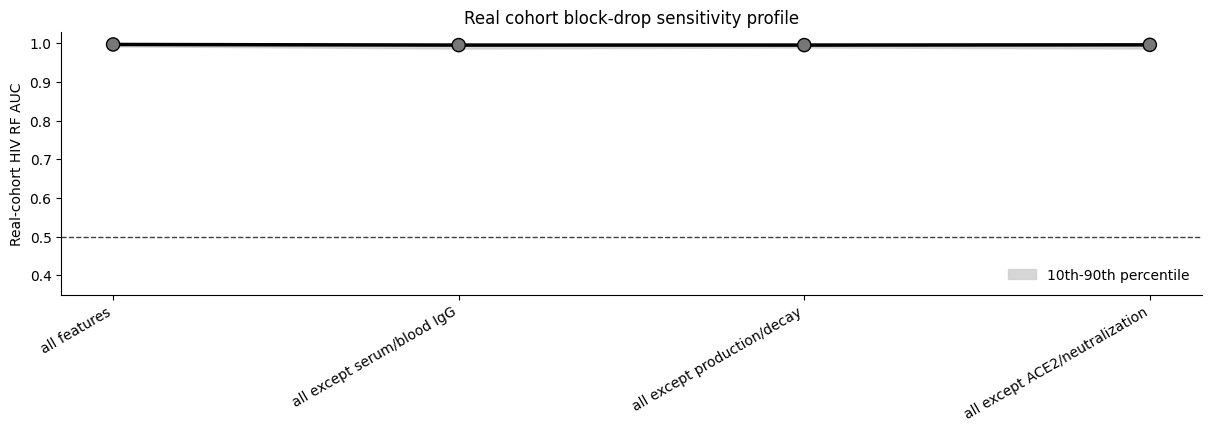

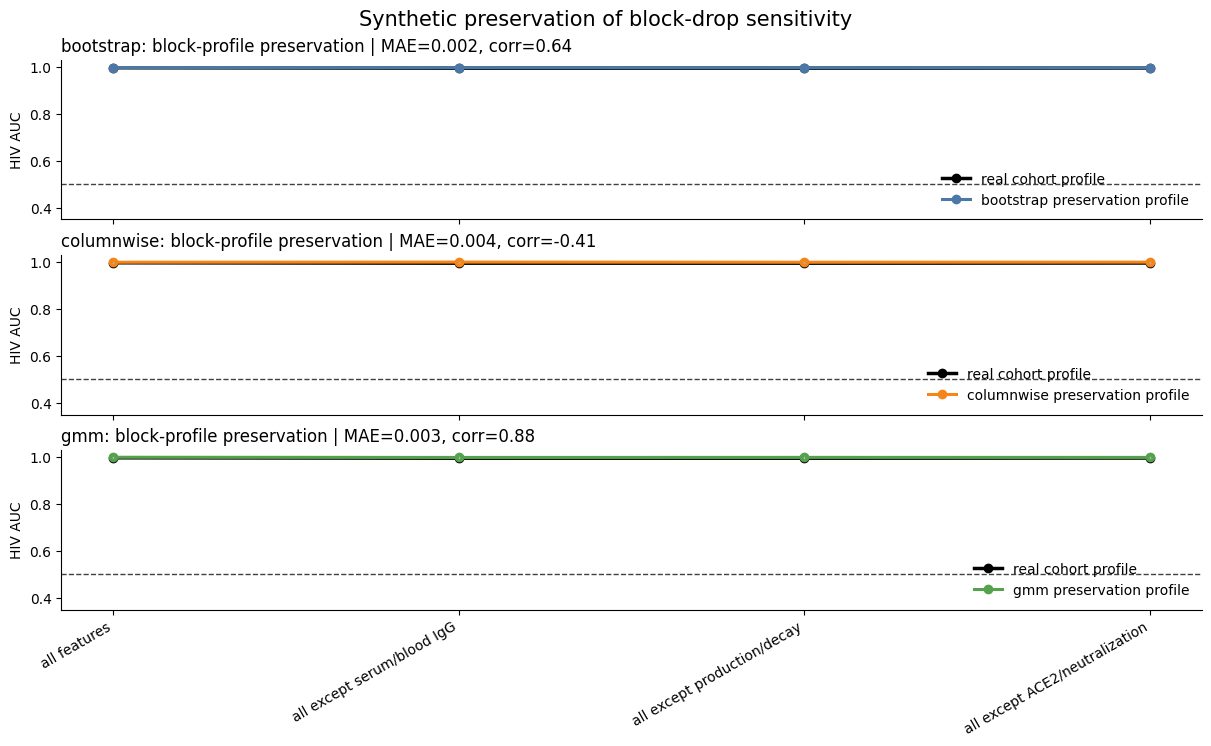

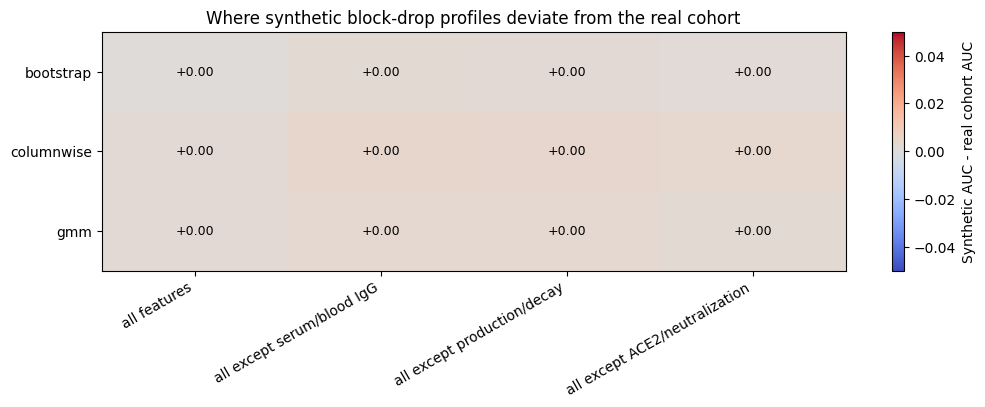

In [4]:
DROP_BLOCKS = ['serum/blood IgG', 'production/decay', 'ACE2/neutralization']
all_idx = set(range(X.shape[1]))
drop_sets = {'all features': np.asarray(sorted(all_idx), dtype=int)}
for block in DROP_BLOCKS:
    drop = set(feature_indices(BIO_BLOCKS[block]))
    drop_sets[f'all except {block}'] = np.asarray(sorted(all_idx - drop), dtype=int)

# For plotting, use a separate order and colors for drop conditions.
DROP_ORDER = list(drop_sets)
BLOCK_ORDER_ORIG = BLOCK_ORDER
BLOCK_ORDER = DROP_ORDER
block_profile = block_profile_rows(drop_sets)
plot_real_profile(block_profile, 'Real cohort block-drop sensitivity profile')
plot_profile_overlay(block_profile, 'Synthetic preservation of block-drop sensitivity')
plot_gap_heatmap(block_profile, 'Where synthetic block-drop profiles deviate from the real cohort')
BLOCK_ORDER = BLOCK_ORDER_ORIG


## Interpretation

Block-only asks whether a block is sufficient. Block-drop asks whether a block is necessary once the full profile is available.

A synthetic generator can match block-only AUCs but fail block-drop sensitivity if it preserves isolated associations while damaging cross-block coordination.